# WASP2026 draft: plot-type accuracy by figure category

A single heatmap panel. It replaces the three-panel "counting and types"
figure this notebook used to build from the `jcdl_followup` run; that code has
been removed, and is in git history if it is ever wanted back.

* **y-axis** -- the low-tier models in the run directory below
* **x-axis** -- what the figure actually is: contour, sky image from a gaussian
  mixture ("fake"), or sky image from a real survey cutout
* **cell value** -- accuracy of the *plot type* question, the same binary
  comparison the original panel uses (exact string match after lowercasing and
  stripping spaces), averaged over the figures in that category

The x-axis is the reason this needs its own parsing rather than the pipeline
above. The plot-type question's ground truth is only `contour` or
`image of the sky` -- it cannot tell a synthetic sky from a real one. The
three-way category comes from the figure's own data (`plot0.distribution` in
the qa json), not from any answer.

These cells are self-contained -- they do not use `parse_lmm_output_utils` or
`results_plotting_utils`, which are not part of this repo.


In [1]:
# ======================== CONFIG ========================
# One row of the figure per run: (row label, directory of per-model pickles).
# All three cover the SAME 150 figures, so the rows differ only by how the page
# was treated before it was sent.
runs = [
    ('original',      '~/astro_sky_image_vqa/LMM_outputs_n150/'),
    ('archive',       '~/astro_sky_image_vqa/LMM_outputs_n150_archive/'),
    ('archive-light', '~/astro_sky_image_vqa/LMM_outputs_n150_archive_light/'),
]

# The full-strength 'archive' aging may not make the paper -- this drops that
# row without touching anything else.
show_archive = False

# Same switch for the archive-light row.  Set False to show ONLY the original
# (unaged) figures -- useful while an aged run is still in progress, since a
# half-finished row otherwise plots as a mostly-empty panel and drags the
# pooled per-category counts around.
show_archive_light = False

# The released VQA jsons -- needed for each figure's true category.
qa_jsons_dir = '~/astro_sky_image_vqa/VQA_full/qa_jsons/'

fig_out_dir = '~/Dropbox/WASP2026/paper_figures/'
fig_name    = 'plot_type_by_category.pdf'

# model subdirectory -> display name, in the order they should appear top to
# bottom.  Same low tier as low_dirs_to_use in the original figure.
model_names = {
    'chatgpt_api':  'GPT',
    'gemini':       'Gemini',
    'claude_haiku': 'Claude',
}

# The plot-type question is asked twice: once offering [contour, image of the
# sky] as a list, once open-ended.  The original figure scores the list variant
# (question_types[0] has 'use list': True).  The open-ended one scores ~0 for
# every model -- they answer things like "Astronomical survey image", which
# never matches the ground-truth string -- so it measures phrasing, not vision.
use_list_variant = True

# Four columns, each a plain accuracy on its own question -- no weighting,
# no conjunction of two answers:
#
#   1  contour   was contour, did it say contour?          (plot-type question)
#   2  sky       was a sky image, did it say sky image?    (plot-type question)
#   |  --- dashed rule: a different question below ---
#   3  synthetic was a GMM sky, did it say gaussian mixture model?  (provenance)
#   4  real      was a real cutout, did it say real image of the sky?
#
# Columns 1-2 come from the plot-type question, whose ground truth is only
# 'contour' or 'image of the sky'; columns 3-4 from the provenance question
# over [gaussian mixture model, real image of the sky].  Two different
# questions, hence the rule between them.
#
# Note the counts differ by column: every sky figure answers the plot-type
# question, so column 2 draws on both sky categories, while 3 and 4 split
# them.  The n printed under each label is counted from the data, not assumed.
four_column_mode = True

# x-axis order and labels
column_order  = ['contour', 'sky', 'synthetic', 'real']
column_labels = {'contour':   'contour',
                 'sky':       'sky image',
                 'synthetic': 'synthetic\n(GMM)',
                 'real':      'real\ncutout'}

show_counts_in_xlabel = True    # append (n=...) to each column label

# Rows are packed close together and only the BOTTOM one keeps its x-axis
# labels, since all rows share the same three categories.
row_gap      = 0.06     # vertical space between rows, as a fraction of row height
row_height_in = 2.2     # height of one row
fig_width_in  = 7.6


In [2]:
import os, json, glob, pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Response parsing lives in models/utils/parse_lmm_output_utils.py, copied from
# the LLM_VQA_MultiPanel project.  Using it rather than a local json.loads:
# models rename the key they were asked for (Claude answers 'plot_types' for
# 'plot types' on 145 of 150 figures) and return trailing commas, single
# quotes and merged answer/explanation objects.  answer_for() matches the
# requested key up to spacing and case; ground_truth() copes with the truth
# being a dict for one question and a bare string for another.
import sys as _sys
_sys.path.insert(0, os.path.abspath(os.path.join('..')))
from utils.parse_lmm_output_utils import (answer_for, expected_key_from_format,
                                          ground_truth, PLACEHOLDER)

# run paths are expanded per row in the PARSE cell
qa_jsons_dir = os.path.expanduser(qa_jsons_dir)
fig_out_dir  = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)


def normalise(x):
    """Match the original panel's comparison: lowercase, spaces stripped."""
    return str(x).lower().replace(' ', '').replace('_', '').strip()


_cat_cache = {}

def figure_category(vqa_id):
    """contour / sky-gmm / sky-real, from the figure's own data."""
    if vqa_id in _cat_cache:
        return _cat_cache[vqa_id]
    with open(os.path.join(qa_jsons_dir, vqa_id + '_qa.json')) as f:
        d = json.loads(json.load(f))
    types, dists = set(), set()
    for k, v in d.items():
        if k.startswith('plot'):
            types.add(v.get('type'))
            dists.add(v.get('distribution'))
    if types == {'contour'}:
        c = 'contour'
    elif types == {'image of the sky'}:
        c = 'sky-gmm' if dists == {'gmm'} else 'sky-real'
    else:
        c = 'other'
    _cat_cache[vqa_id] = c
    return c


In [3]:
# ======================== PARSE ========================
# One row of the figure per run; all three cover the same 150 figures, so a
# difference between rows is a difference in how the page was degraded.
_hidden = set()
if not show_archive:
    _hidden.add('archive')
if not globals().get('show_archive_light', True):
    _hidden.add('archive-light')
active_runs = [(lab, d) for lab, d in runs if lab not in _hidden]
if not active_runs:
    raise ValueError('every run is hidden -- turn one of the show_* flags back on')

rows = []
for run_label, run_path in active_runs:
    run_path = os.path.expanduser(run_path)
    for mdir, mname in model_names.items():
        pkls = sorted(glob.glob(os.path.join(run_path, mdir, '*_qa.pickle')))
        if not pkls:
            print('[WARN] no pickles in', os.path.join(run_path, mdir))
            continue
        for fp in pkls:
            vqa_id = os.path.basename(fp).removesuffix('_qa.pickle')
            with open(fp, 'rb') as f:
                payload = pickle.load(f)
            qa_list = payload[0] if isinstance(payload, (list, tuple)) else payload
            model_id = (payload[1] if isinstance(payload, (list, tuple)) and len(payload) > 1
                        else mdir)

            def _model_answer(entry):
                """The model's answer, keyed by whatever the prompt asked for."""
                return answer_for(entry.get('raw answer') or entry.get('Response'),
                                  expected_key_from_format(entry.get('format')))

            ptype = dist = None
            for e in qa_list:
                q = (e.get('question') or '').lower()

                if 'plot type' in q:
                    # the two variants differ only by the multiple-choice list
                    offers_list = 'please choose' in (e.get('context') or '').lower()
                    if offers_list != use_list_variant:
                        continue
                    ptype = (ground_truth(e), _model_answer(e))

                elif 'underlying distribution' in q and 'color-axis' not in q:
                    # the SKY provenance question: [gaussian mixture model,
                    # real image of the sky].  The 'color-axis' variant is the
                    # contour one over [random, linear, gmm] -- a different
                    # question, deliberately excluded.  Note contour figures
                    # also ask an 'in the x/y-plane' variant with no axis
                    # qualifier; those are filtered out by category below.
                    dist = (ground_truth(e), _model_answer(e))

            if ptype is None:
                continue
            truth, answer = ptype
            # nothing usable came back: no json block, or only an explanation.
            # Counted as wrong below, but tracked separately -- a model that
            # cannot be parsed is failing differently from one that answers the
            # wrong category.
            parsed = answer is not None and str(answer).strip() != ''
            correct = int(normalise(truth) == normalise(answer))

            category = figure_category(vqa_id)

            # One row per (figure, MEASURE).  The plot-type question is asked of
            # every figure; the provenance question only of sky figures.  Keeping
            # them as separate rows is what lets each column be a plain accuracy
            # over its own denominator instead of a conjunction.
            base = {'run': run_label, 'model': mname, 'model_id': model_id,
                    'vqa_id': vqa_id, 'category': category}

            rows.append(dict(base, column=('contour' if category == 'contour' else 'sky'),
                             measure='plot type', truth=truth, answer=answer,
                             parsed=parsed, correct=correct))

            if four_column_mode and category in ('sky-gmm', 'sky-real'):
                if dist is None:
                    d_truth = d_answer = None
                    d_parsed, d_correct = False, 0
                else:
                    d_truth, d_answer = dist
                    d_parsed = d_answer is not None and str(d_answer).strip() != ''
                    d_correct = int(normalise(d_truth) == normalise(d_answer))
                rows.append(dict(base,
                                 column=('synthetic' if category == 'sky-gmm' else 'real'),
                                 measure='provenance', truth=d_truth, answer=d_answer,
                                 parsed=d_parsed, correct=d_correct))

dfcat = pd.DataFrame(rows)
print('rows to plot:', ', '.join(lab for lab, _ in active_runs))
print()
for lab, _ in active_runs:
    sel = dfcat[dfcat['run'] == lab]
    print('  %-14s %5d answers, %3d figures, %d models'
          % (lab, len(sel), sel['vqa_id'].nunique(), sel['model'].nunique()))
print()
print('figures per category (per run):')
print(dfcat.groupby(['run', 'category'])['vqa_id'].nunique().unstack().to_string())

print()
print('UNPARSEABLE answers (no usable json came back; scored as wrong):')
unp = (dfcat.assign(unparseable=~dfcat['parsed'])
            .groupby(['run', 'model'])['unparseable'].agg(['sum', 'count']))
unp['pct'] = 100.0 * unp['sum'] / unp['count']
unp.columns = ['unparseable', 'answers', '%']
print(unp.to_string(float_format=lambda v: '%.1f' % v))
if unp['unparseable'].sum() == 0:
    print('   (none)')
dfcat.head()


<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:2: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:2: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:2: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:2: SyntaxWarning: inv

rows to plot: original

  original         750 answers, 150 figures, 3 models

figures per category (per run):
category  contour  sky-gmm  sky-real
run                                 
original       50       50        50

UNPARSEABLE answers (no usable json came back; scored as wrong):
                 unparseable  answers   %
run      model                           
original Claude            0      250 0.0
         GPT               0      250 0.0
         Gemini            0      250 0.0
   (none)


,run,model,model_id,vqa_id,category,column,measure,truth,answer,parsed,correct
0,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000001,sky-gmm,sky,plot type,image of the sky,contour,True,0
1,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000001,sky-gmm,synthetic,provenance,gaussian mixture model,real image of the sky,True,0
2,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000002,sky-real,sky,plot type,image of the sky,image of the sky,True,1
3,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000002,sky-real,real,provenance,real image of the sky,real image of the sky,True,1
4,original,GPT,gpt-5.4-nano-2026-03-17,vqa_000003,sky-real,sky,plot type,image of the sky,image of the sky,True,1


## The exact questions behind each panel

What was actually sent to the models, pulled from the run pickles rather than


In [4]:
# ============ the exact wording behind each panel ============
# Printed from the run pickles, not retyped, so this cannot drift from what was
# actually asked.  Each entry carries the pieces separately (persona, context,
# question, format, reasoning) and the assembled `prompt` that went to the API.

_WANTED = [
    ('plot type  [list variant -- the one scored]',
     lambda q, ol: 'plot type' in q and ol),
    ('plot type  [open-ended -- not scored]',
     lambda q, ol: 'plot type' in q and not ol),
    ('provenance  [sky figures -- right panel]',
     lambda q, ol: 'underlying distribution' in q and 'color-axis' not in q),
    ('distribution  [contour figures -- NOT in this figure]',
     lambda q, ol: 'underlying distribution' in q and 'color-axis' in q),
]

_found = {k: None for k, _ in _WANTED}
_probe_run = os.path.expanduser(active_runs[0][1])
for _fp in sorted(glob.glob(os.path.join(_probe_run, list(model_names)[0], '*_qa.pickle'))):
    with open(_fp, 'rb') as _f:
        _payload = pickle.load(_f)
    _qa = _payload[0] if isinstance(_payload, (list, tuple)) else _payload
    for _e in _qa:
        _q = (_e.get('question') or '').lower()
        _ol = 'please choose' in (_e.get('context') or '').lower()
        for _k, _test in _WANTED:
            if _found[_k] is None and _test(_q, _ol):
                _found[_k] = _e
    if all(v is not None for v in _found.values()):
        break

for _k, _e in _found.items():
    print('=' * 78)
    print(_k)
    print('=' * 78)
    if _e is None:
        print('  (no example found in this run)\n')
        continue
    print('  SIMPLE (the question alone, as matched in the parse above):')
    print('    %s' % _e.get('question'))
    print()
    print('  CHOICES OFFERED:')
    print('    %s' % ((_e.get('context') or '').strip() or '(none -- open-ended)'))
    print()
    print('  ANSWER FORMAT:')
    print('    %s' % (_e.get('format') or '').strip())
    print()
    print('  FULL PROMPT as sent:')
    print('    %s' % _e.get('prompt'))
    print()


plot type  [list variant -- the one scored]
  SIMPLE (the question alone, as matched in the parse above):
    What is the plot type of the plot in this figure?

  CHOICES OFFERED:
    Please choose the plot type from the following list: [contour, image of the sky].

  ANSWER FORMAT:
    Please format the output as a json as {"plot types":[]}, where the list holds the plot type of the plot as its only element.

  FULL PROMPT as sent:
    I am going to show you an image. Now, please choose the plot type from the following list: [contour, image of the sky]. What is the plot type of the plot in this figure? Please format the output as a json as {"plot types":[]}, where the list holds the plot type of the plot as its only element.  In addition to providing your answer, please provide your reasoning.  Include this as a separate JSON snippet formatted as {"explanation":""} and fill in your reasoning as a string.  Your answer should only include the answer JSON and the explanation JSON snippet

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/plot_type_by_category_four_column.pdf

--- original ---
column  contour    sky  synthetic  real
model                                  
GPT        66.0   48.0        8.0  96.0
Gemini     80.0  100.0        8.0  96.0
Claude     18.0  100.0        0.0  96.0


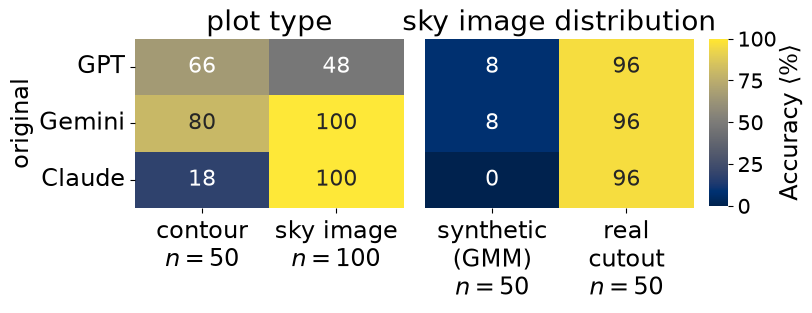

In [5]:
# ======================== PLOT ========================
fontsize           = 20
tick_fontsize      = 17
barfontsize        = 17
cbar_tick_fontsize = 15
annot_fontsize     = 16
annot_fmt          = '.0f'
cmap               = 'cividis'   # yellow = highest accuracy
                                 # ('cividis_r' puts yellow at the low end)
barpad             = 2
rowlabel_fontsize  = 17
acctag             = r'Accuracy $\mathrm{\langle \% \rangle}$'

# Gap between the plot-type block and the provenance block, as a fraction of
# panel width -- the horizontal counterpart of row_gap.  A real break rather
# than a rule inside one heatmap: the two blocks answer different questions
# over different denominators, so they are not one continuous scale, and each
# gets its own title above its own panel.
panel_gap = 0.08

row_labels = [lab for lab, _ in active_runs]
nrows = len(row_labels)

# Which columns belong to which panel, and what each panel is called.
panels = ([('plot type',  ['contour', 'sky']),
           ('sky image distribution', ['synthetic', 'real'])]
          if four_column_mode else
          [('plot type', list(column_order))])

# one pivot per row, on a fixed model x column grid so every row lines up
pivots = {}
for lab in row_labels:
    sel = dfcat[dfcat['run'] == lab]
    pv = (sel.pivot_table(index='model', columns='column',
                          values='correct', aggfunc='mean') * 100)
    pv = pv.reindex([v for v in model_names.values() if v in pv.index])
    pv = pv.reindex(columns=[c for c in column_order if c in pv.columns])
    pivots[lab] = pv

# counted from the data, not assumed: the columns have different denominators
# (every sky figure answers the plot-type question, so 'sky' pools both sky
# categories, while 'synthetic' and 'real' split them).
counts = dfcat.groupby('column')['vqa_id'].nunique()


def _xlabel(c):
    lab = column_labels.get(c, c)
    if show_counts_in_xlabel:
        lab += '\n$n=%d$' % counts.get(c, 0)
    return lab


# columns actually present, per panel
panel_cols = [(t, [c for c in cols if c in pivots[row_labels[0]].columns])
              for t, cols in panels]
panel_cols = [(t, cols) for t, cols in panel_cols if cols]
ncols = len(panel_cols)

fig, axes = plt.subplots(nrows, ncols, squeeze=False,
                         figsize=(fig_width_in, row_height_in * nrows),
                         gridspec_kw={'hspace': row_gap,
                                      'wspace': panel_gap,
                                      'right': 0.86,
                                      # panels sized by how many columns they
                                      # hold, so every cell stays square-ish
                                      'width_ratios': [len(c) for _, c in panel_cols]})

# one shared colorbar for the whole figure: the scale is identical everywhere
cbar_ax = fig.add_axes([0.88, 0.12, 0.025, 0.76])

for i, lab in enumerate(row_labels):
    last_row = (i == nrows - 1)
    for j, (ptitle, cols) in enumerate(panel_cols):
        ax = axes[i][j]
        first_col = (j == 0)
        sns.heatmap(pivots[lab][cols], annot=True, fmt=annot_fmt, cmap=cmap,
                    vmin=0, vmax=100, ax=ax,
                    annot_kws={'size': annot_fontsize},
                    cbar=(i == 0 and j == 0),
                    cbar_ax=(cbar_ax if (i == 0 and j == 0) else None))
        ax.set_xlabel('')
        # model names only on the leftmost panel; the run label sits outside them
        if first_col:
            ax.set_ylabel(lab, fontsize=rowlabel_fontsize)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
        else:
            ax.set_ylabel('')
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        # x tick labels only on the bottom row -- every row shares the columns
        if last_row:
            ax.set_xticklabels([_xlabel(c) for c in cols], fontsize=tick_fontsize)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', length=0)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        # each panel titles itself, centred on its own axes -- no manual
        # positioning needed now that the break is structural
        if i == 0:
            ax.set_title(ptitle, fontsize=fontsize)

cbar_ax.set_ylabel(acctag, fontsize=barfontsize, labelpad=barpad)
cbar_ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
cbar_ax.tick_params(labelsize=cbar_tick_fontsize)

# distinct filename per metric, so the two do not overwrite each other
_name = (fig_name.replace('.pdf', '_four_column.pdf')
         if four_column_mode else fig_name)
out_path = os.path.join(fig_out_dir, _name)
fig.savefig(out_path, bbox_inches='tight')
print('wrote', out_path)
print()
for lab in row_labels:
    print('--- %s ---' % lab)
    print(pivots[lab].round(1).to_string())


## Other plots